In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tushare as ts
import akshare as ak
import time
import warnings
warnings.filterwarnings("ignore")

In [31]:
TS_TOKEN = '4fc81c60f80ca9365c693161c1cb4d25915a37b783bf0b88fd204e9a' 
ts.set_token(TS_TOKEN)

START_DATE = '20240501'
END_DATE = '20240531'
TOP_N = 50
PREDS_FILE = Path("results/lightgbm_preds_2024.csv")

In [32]:
def normalize_stock_code(code):
    code = str(code).strip()

    if code.startswith('6'):
        return f"{code}.SH"

    if code.startswith('0'):
        return f"{code}.SZ"

    return None # Only handle SZ and SH markets

df_preds = pd.read_csv(PREDS_FILE)
df_preds['symbol'] = df_preds['symbol'].astype(str).str.zfill(6)

selected_symbols = df_preds.nlargest(TOP_N, 'predicted_return')['symbol'].tolist()
ts_codes = [normalize_stock_code(sym) for sym in selected_symbols]
ts_codes

['000601.SZ',
 '000670.SZ',
 '002189.SZ',
 '002446.SZ',
 '002472.SZ',
 '002514.SZ',
 '688222.SH',
 '688737.SH',
 '002051.SZ',
 '600215.SH',
 '600506.SH',
 '600527.SH',
 '600686.SH',
 '600733.SH',
 '603089.SH',
 '603129.SH',
 '603319.SH',
 '603409.SH',
 '603657.SH',
 '603681.SH',
 '603926.SH',
 '603969.SH',
 '688021.SH',
 '688237.SH',
 '688255.SH',
 '688717.SH',
 '000695.SZ',
 '000988.SZ',
 '001359.SZ',
 '002055.SZ',
 '002369.SZ',
 '002885.SZ',
 '002959.SZ',
 '601677.SH',
 '603042.SH',
 '603214.SH',
 '603527.SH',
 '603551.SH',
 '605005.SH',
 '605060.SH',
 '688066.SH',
 '688195.SH',
 '688205.SH',
 '688522.SH',
 '688636.SH',
 '688678.SH',
 '000536.SZ',
 '000733.SZ',
 '000751.SZ',
 '000777.SZ']

In [33]:
stock_data_list = []
    
for code in ts_codes:
    try:
        df = ts.pro_bar(ts_code=code, adj='qfq', start_date=START_DATE, end_date=END_DATE)
        if df is not None and not df.empty:
            df['daily_return'] = df['pct_chg'] / 100.0 # Tushare returns are in percentage, convert to decimal
            stock_data_list.append(df[['trade_date', 'ts_code', 'daily_return']])
        time.sleep(0.1) # Sleep to avoid hitting API rate limits
    except Exception as e:
        print(f"Error fetching data for {code}: {e}")

if not stock_data_list:
    print("No stock data fetched. Please check the stock codes and API access.")
        
df_portfolio = pd.concat(stock_data_list, ignore_index=True)
strategy_daily = df_portfolio.groupby('trade_date')['daily_return'].mean().reset_index() # Equal-weighted average return
strategy_daily.rename(columns={'daily_return': 'Strategy_Return'}, inplace=True)
strategy_daily['trade_date'] = pd.to_datetime(strategy_daily['trade_date'])
strategy_daily

,trade_date,Strategy_Return
0,2024-05-06,0.026322
1,2024-05-07,0.009194
2,2024-05-08,-0.020027
3,2024-05-09,0.017341
4,2024-05-10,-0.010069
5,2024-05-13,-0.018155
6,2024-05-14,0.013945
7,2024-05-15,-0.010745
8,2024-05-16,0.007702
9,2024-05-17,0.013718


In [34]:
df_hs300 = ak.stock_zh_index_daily(symbol="sz399300")
df_hs300['trade_date'] = pd.to_datetime(df_hs300['date'])
df_hs300['pct_chg'] = df_hs300['close'].pct_change()
df_hs300 = df_hs300[(df_hs300['trade_date'] >= START_DATE) & (df_hs300['trade_date'] <= END_DATE)]
df_hs300['HS300_Return'] = df_hs300['pct_chg']
df_hs300 = df_hs300[['trade_date', 'HS300_Return']]
df_hs300

,trade_date,HS300_Return
5415,2024-05-06,0.014838
5416,2024-05-07,0.000309
5417,2024-05-08,-0.007867
5418,2024-05-09,0.009459
5419,2024-05-10,0.000468
5420,2024-05-13,-0.000433
5421,2024-05-14,-0.002086
5422,2024-05-15,-0.008474
5423,2024-05-16,0.003945
5424,2024-05-17,0.010331


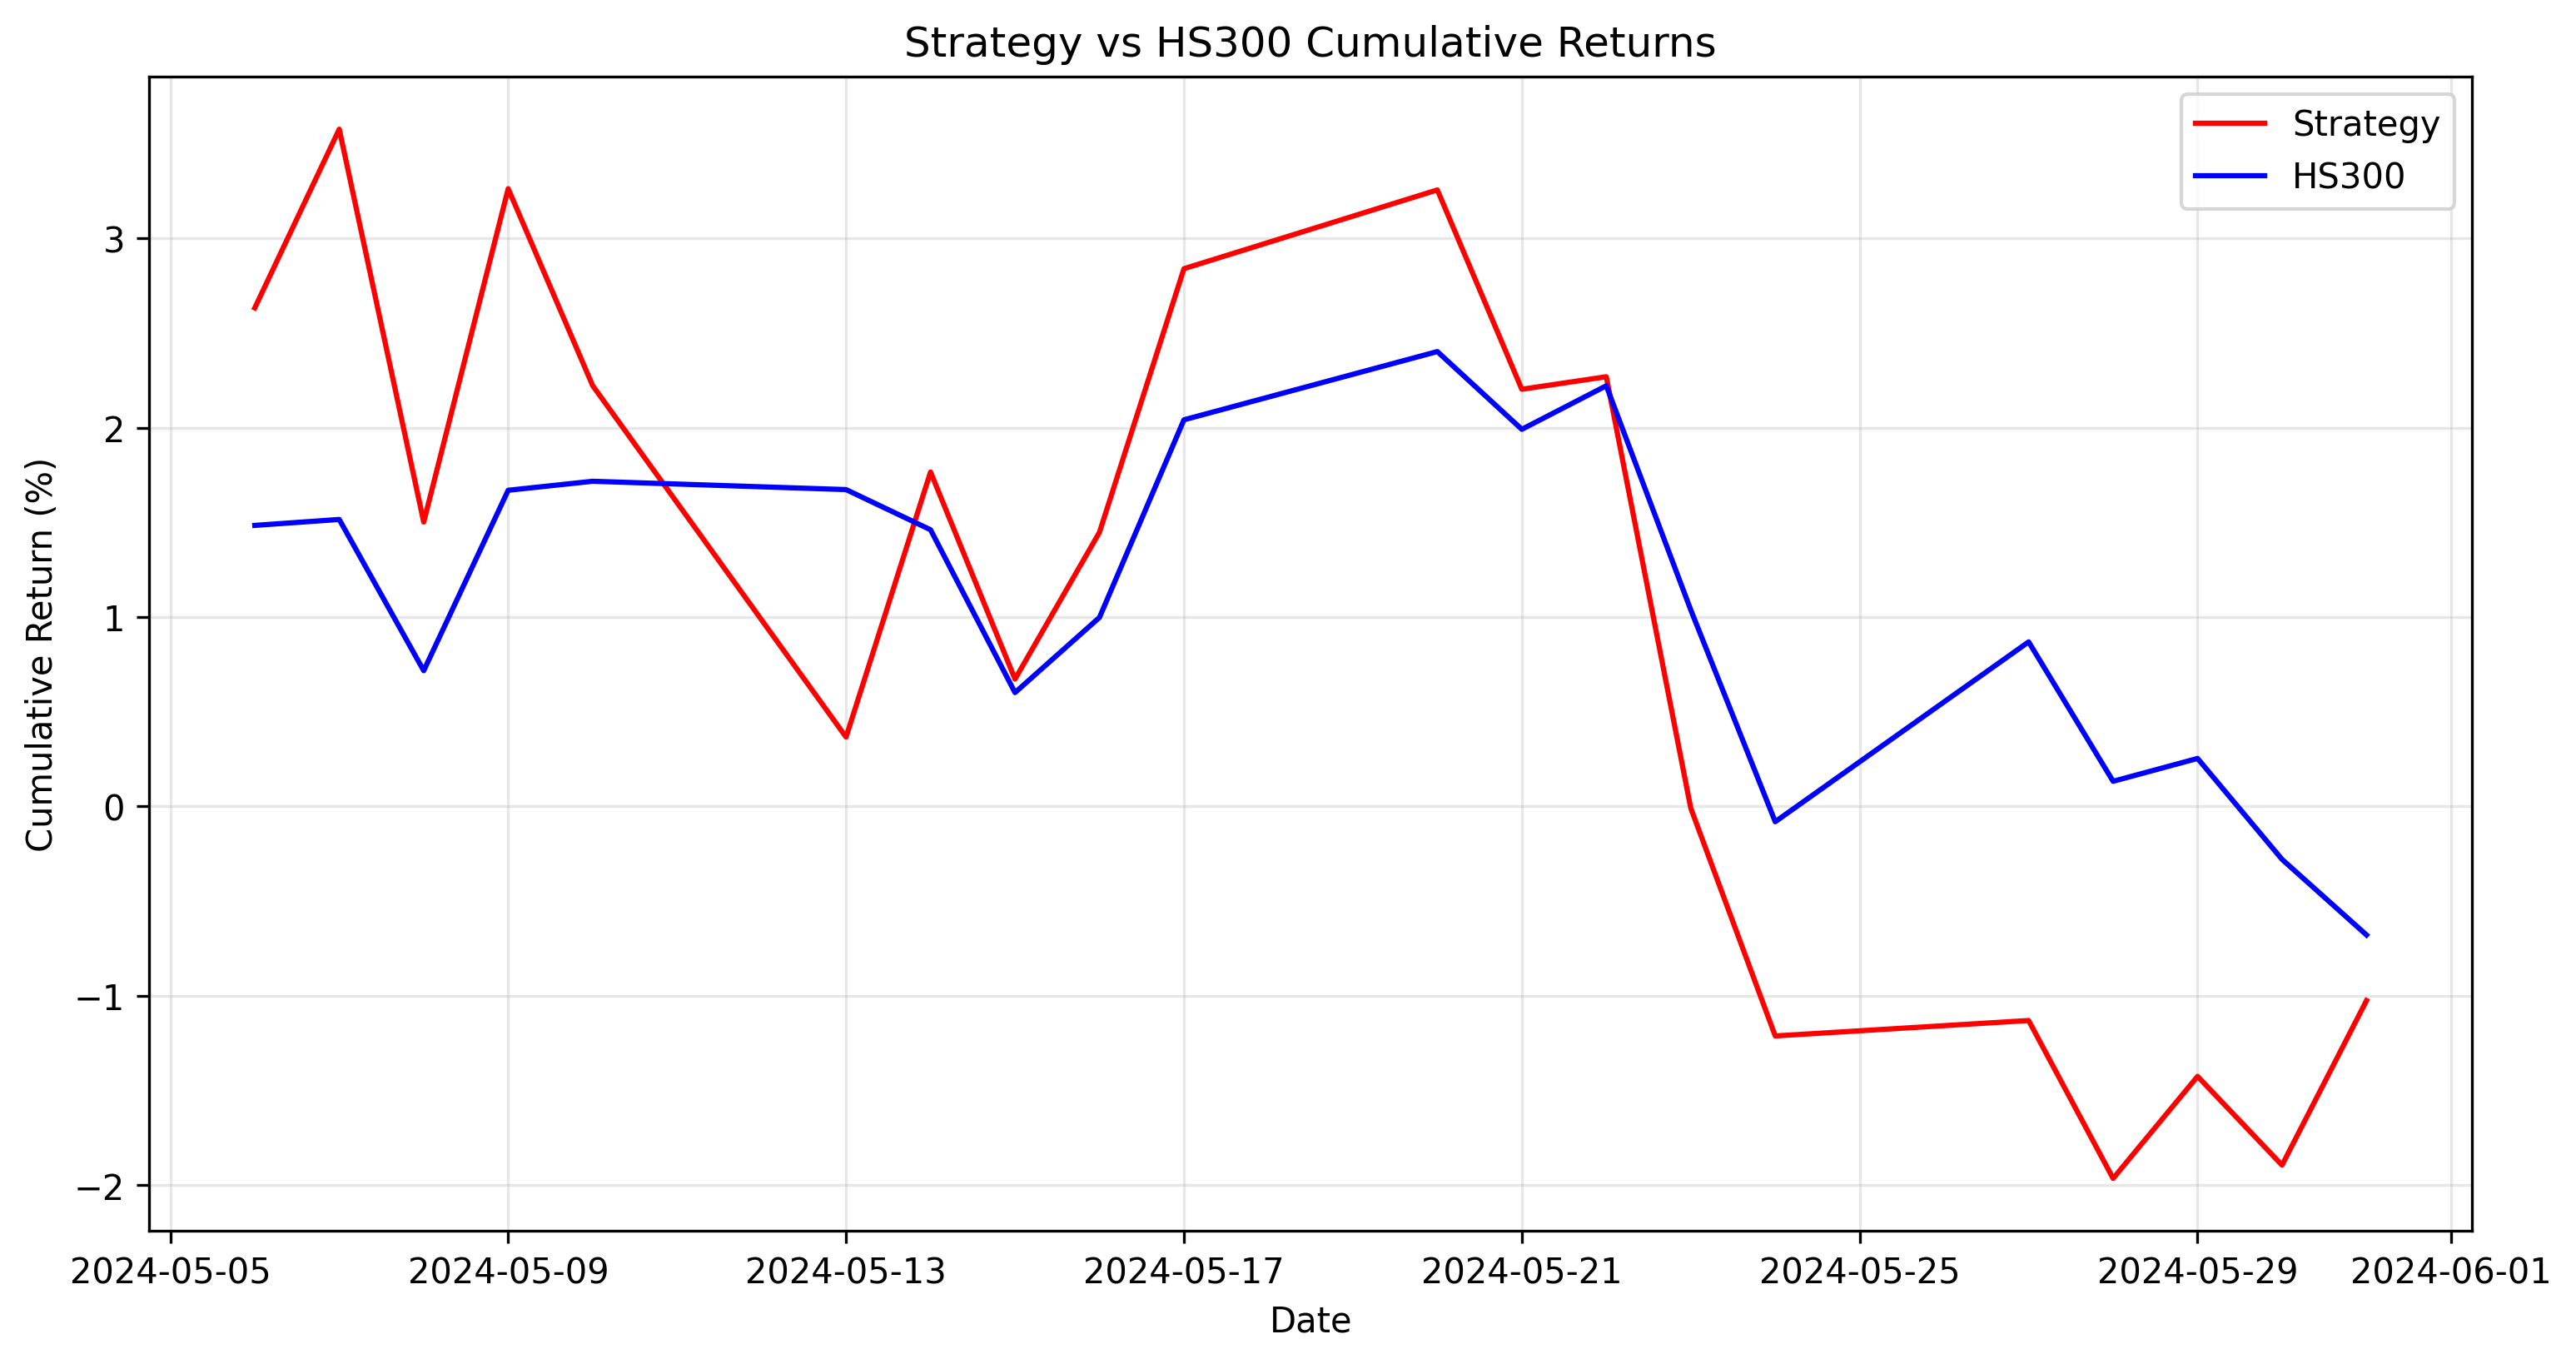

In [36]:
df_plot = pd.merge(strategy_daily, df_hs300, on='trade_date', how='inner')
df_plot.set_index('trade_date', inplace=True)
df_plot.sort_index(inplace=True)

df_plot['Strategy_Cum'] = (1 + df_plot['Strategy_Return']).cumprod() - 1
df_plot['HS300_Cum'] = (1 + df_plot['HS300_Return']).cumprod() - 1

plt.figure(figsize=(12, 6), dpi=300)
plt.plot(df_plot.index, df_plot['Strategy_Cum'] * 100, label='Strategy', color='red')
plt.plot(df_plot.index, df_plot['HS300_Cum'] * 100, label='HS300', color='blue')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.title('Strategy vs HS300 Cumulative Returns')
plt.legend()
plt.grid(alpha=0.3)
plt.show()